# Autoregressive models using a feedforward neural network 
## PART 2: Applying the methods to health care time series

In this notebook we will use a feedforward neural network to fit a single and ensemble linear and non-linear models to real time series data. 

<div class="alert alert-info">
    
1. Most of the work we will do is data manipulation: preprocessing data and making sure it is the right shape for the neural networks.

2. The ensemble learning method can be computationally expensive.  We have included some pre-trained models that can be loaded from file if needed.
</div>

---
**LEARNING OBJECTIVES**

* Learn how to apply feedforward neural networks to real health data.
* Methods to preprocess nn input data.
* Recognise the stochastic nature of neural network training
* Use a ensemble of neural networks to provide a more reliable point forecast
---


**Here is a general plan to use with each model:**

1. Conduct a temporal train test split on the raw data into train and test (12 months).
2. Scale the data ready for a neural network by fitting ONLY on train. Transform train.
3. Tabularise the training data ready to train the neural network model.
4. Fit the data to the model
5. Forecast by taking the last window of the training set and iterating forward 12 times.

# Python dependencies

It is recommended that you use the forecasting course conda environment provided. We are again going to implement neural networks using `tensorflow` and '`keras`. You should be using at least `tensorflow` version `2.1.15`.

In [1]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
import seaborn as sns
sns.set()

#  tensorflow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

from forecast_tools.metrics import root_mean_squared_error



from sklearn.preprocessing import MinMaxScaler

tf.__version__

2026-01-27 16:29:46.767809: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 16:29:46.783661: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


'2.15.0'

# Forecasting emergency admissions in England

We will now use feedforward neural networks to predict the number of monthly emergency admissions in England. 

## Load the data

**Task**:
* Execute the code below to read the emergency admissions data into pandas

In [2]:
url = 'https://raw.githubusercontent.com/health-data-science-OR/data/master' \
        + '/em_admits_ts.csv'
em_admits = pd.read_csv(url)

In [3]:
em_admits.head(3)

,month_year,em_admits
0,Aug-10,425702
1,Sep-10,424900
2,Oct-10,436215


In [4]:
em_admits.shape

(111, 2)

## 2.3. Preprocessing 

### 2.3.1 Datetime format

Notice the the `month_year` column in `em_admits` holds a string an invalid date format e.g. 'Aug-10'.  Pandas cannot handle this as-is because '10' could refer to any century!  So let's do a bit of preprocessing to get it into a valid datetime format.


*Optional Task:*
* Take some time to understand the code that preprocesses the dates.  This is real health data and it is likely you will need to deal with formatting issues as experienced here.

First we will format the string to something pandas can parse i.e. 'Aug 2010'.  Then we will call the `pd.to_datetime()` function to parse the string and return a `datetime`.  We will assign the result to our dataframe's index and set the freq to monthly start 'MS'

In [5]:
date_str = em_admits['month_year'].str[:3] + ' 20' \
    + em_admits['month_year'].str[-2:]
date_str.name = 'date'
em_admits = em_admits.set_index(pd.to_datetime(date_str))
em_admits.index.freq = 'MS'
em_admits = em_admits.drop(columns=['month_year'])

/tmp/ipykernel_807704/1699978285.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  em_admits = em_admits.set_index(pd.to_datetime(date_str))


In [6]:
em_admits.head()

,em_admits
date,
2010-08-01,425702
2010-09-01,424900
2010-10-01,436215
2010-11-01,429099
2010-12-01,452728


### 2.3.2 Visualise the training data

We will be forecasting the last 12 months of the series.  Let's take a look at the training data (being careful to exclude the last 12 months)

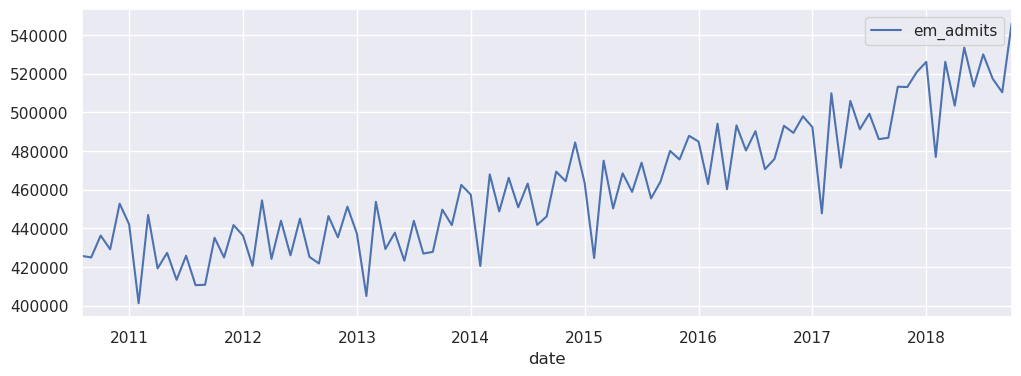

In [7]:
holdout_length = 12
em_admits[:len(em_admits)-holdout_length].plot(figsize=(12,4));

### 2.3.3 Calender adjustment

This is monthly data so a useful preprocessing step is to transform the data into a daily rate by dividing by the number of days in the month. When we plot this the troughs we saw in Feb each year disappear.

**execute the code below which:**:
* Calculates the average admissions per day series
* Plots the training data (holding back 12 months for testing)

In [8]:
admit_rate = em_admits['em_admits'] / em_admits.index.days_in_month

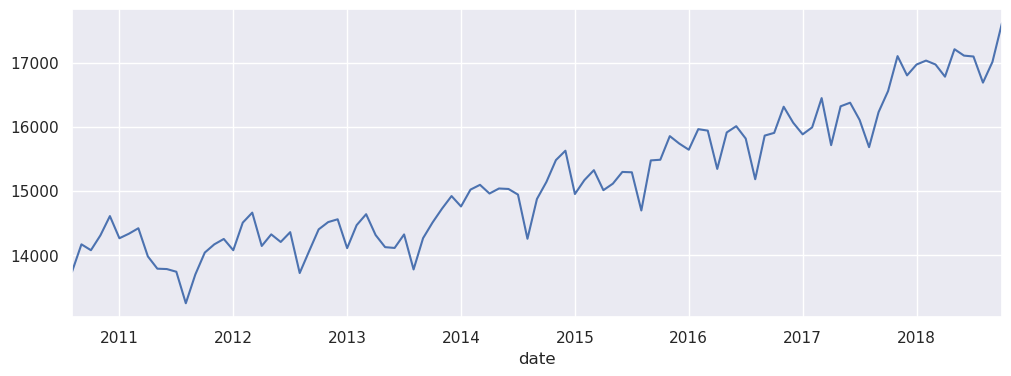

In [9]:
admit_rate[:len(admit_rate)-12].plot(figsize=(12,4));

### 2.3.4 Temporal Train-Test Split

We will formally split the data so that we hold out 12 months for comparison of forecasting metrics

In [10]:
holdout_length = 12
admit_rate_train = admit_rate[:len(admit_rate)-holdout_length]
admit_rate_test = admit_rate[-holdout_length:]

print(admit_rate_train.shape)
print(admit_rate_test.shape)

(99,)
(12,)


## **Exercise 1**: Process the time series to format suitable for supervised learning.

### Scaling the features and target to be between -1 and 1
In many machine learning applications data are scaled to be between 0 and 1. For neural network forecasting, *Ord, Fildes and Kourentzes (2017)* recommend scaling to be between -1 and 1.  This is what we will do here.  To do the scaling we will use

```python
sklearn.preprocessing.MinMaxScaler
```

> Execute the code below to transform the data.

In [11]:
# Reshape to 2D array (n_samples, 1) as required by MinMaxScaler
train_reshaped = admit_rate_train.values.reshape(-1, 1)

# Create the scaler
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit the scaler ONLY on training data
scaler.fit(train_reshaped)

# Transform the training data
train_scaled = scaler.transform(train_reshaped).reshape(-1, )

print(f"Scaled Train Min: {train_scaled.min()}")
print(f"Scaled Train Max: {train_scaled.max()}")
print(f"Scaled Train Shape: {train_scaled.shape}")

Scaled Train Min: -1.0
Scaled Train Max: 0.9999999999999991
Scaled Train Shape: (99,)


### Tabularise the training data

The function `sliding_window` has been provided below for you to create your training data.

**Task**:
* Using a sliding window approach convert the time series into a tabular format. 
 * Use a window size of 12 and assume you are predicting a scalar value of y (1-step ahead).
* Conduct a train test split holding back 12 windows as a test set.

In [12]:
def sliding_window(train, window_size=2, horizon=1):
    '''
    sliding window.
    
    Parameters:
    --------
    train: array-like
        training data for time series method
    
    window_size: int, optional (default=2)
        lookback - how much lagged data to include.
        
    horizon: int, optional (default=1)
        number of observations ahead to predict
            
    Returns:
        array-like, array-like
    
        preprocessed X, preprocessed Y
    '''
    tabular_X = []
    tabular_y = []
    for i in range(0, len(train) - window_size - horizon + 1):
        X_train = train[i:window_size+i]
        y_train = train[i+window_size+horizon-1]
        tabular_X.append(X_train)
        tabular_y.append(y_train)
       
    return np.asarray(tabular_X), np.asarray(tabular_y).reshape(-1, )

In [13]:
WINDOW_SIZE = 12
X_train, y_train = sliding_window(train_scaled, window_size=WINDOW_SIZE)

In [14]:
X_train.shape

(87, 12)

In [15]:
y_train.shape

(87,)

Let's convince ourselves that our data is in tabular format suitable for regression.  The code below converts the windows to a `DataFrame` so we can easily visualise it.

In [16]:
def convert_windows_to_dataframe(X_data, y_data) -> pd.DataFrame:
    """
    Utility function for converting the window format data into 
    a pandas dataframe
    """
    tabular_form = pd.concat([pd.DataFrame(X_data), pd.DataFrame(y_data)], axis=1)
    columns = [f'lag_{i}' for i in range(len(X_train[0]), 0, -1)]
    columns.append('y_t')
    tabular_form.columns = columns
    return tabular_form

In [17]:
# create the dataframe and round 2 dp.
convert_windows_to_dataframe(X_train, y_train).head().round(2)

,lag_12,lag_11,lag_10,lag_9,lag_8,lag_7,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,y_t
0,-0.78,-0.58,-0.62,-0.52,-0.38,-0.54,-0.50,-0.46,-0.67,-0.75,-0.76,-0.77,-1.00
1,-0.58,-0.62,-0.52,-0.38,-0.54,-0.50,-0.46,-0.67,-0.75,-0.76,-0.77,-1.00,-0.79
2,-0.62,-0.52,-0.38,-0.54,-0.50,-0.46,-0.67,-0.75,-0.76,-0.77,-1.00,-0.79,-0.64
3,-0.52,-0.38,-0.54,-0.50,-0.46,-0.67,-0.75,-0.76,-0.77,-1.00,-0.79,-0.64,-0.58
4,-0.38,-0.54,-0.50,-0.46,-0.67,-0.75,-0.76,-0.77,-1.00,-0.79,-0.64,-0.58,-0.54


# **Exercise 2**: A Linear regression model benchmark

The first model we will try is the linear model. Its will serve as our neural network baseline.  (In practice we would also check this is better than a naive method such as seasonal naive).

## Exercise 2a Train the model

**Task:**
* Using `Keras`, construct a neural network that mimics a simple linear regression model (see previous notebook).  
* Optional: To get comparable results, set the tensorflow random number seed to 1234
* Train the model for 100 epochs.
* Optionally you can use an early stopping callback with patience set to 10.

In [18]:
# example answer
def get_linear_model(ws, lr=0.01, metrics=None):
    '''
    Sequential Keras model that minics
    AR linear model. 
    '''
    if metrics is None:
        metrics = ['mae', 'mse']
    
    model = Sequential([Dense(1, input_shape=(ws,))])
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=lr),
                  metrics=metrics)
    
    return model

In [19]:
# set tensorflow random seed for repeatability
tf.random.set_seed(1234)

N_EPOCHS = 100
es = EarlyStopping(monitor='val_loss', patience=10)

# call the linear model function create earlier.
model_lm = get_linear_model(ws=12, metrics=['mae'])

# fit model silently (verbose=0)
results = model_lm.fit(
    x=X_train, 
    y=y_train, 
    epochs=N_EPOCHS,
    validation_split=0.1,
    verbose=0,
    callbacks=[es]
)

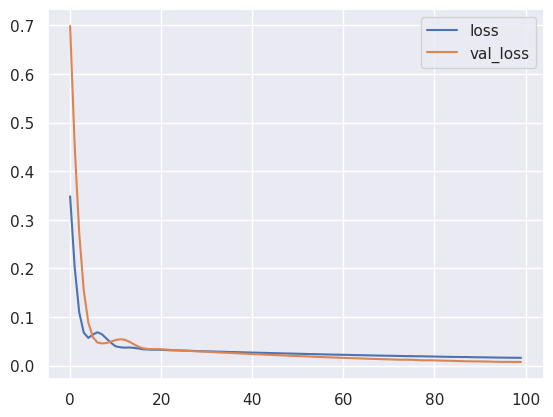

In [20]:
_ = plt.plot(results.history['loss'], label='loss')
_ = plt.plot(results.history['val_loss'], label='val_loss')
_ = plt.legend()

## Extra: Plot the fitted values

To see the in-sample fitted values (predicting the training data) we first need to back transform the predictions using the `scaler`.

3/3 [==============================] - 0s 592us/step


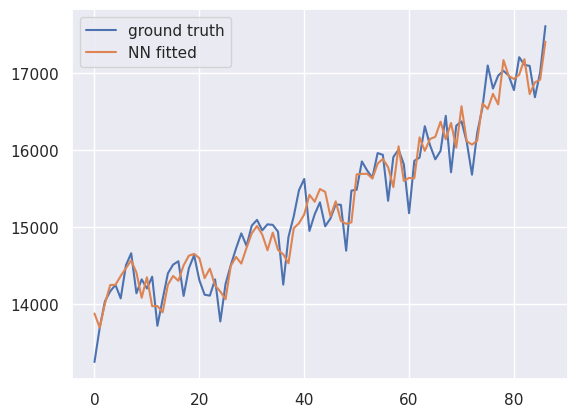

In [21]:
# make the predictions
in_sample_preds = model_lm.predict(X_train)

# back transform to original units
back_transformed_preds = scaler.inverse_transform(in_sample_preds)

_ = plt.plot(scaler.inverse_transform(y_train.reshape(-1, 1)), label='ground truth')
_ = plt.plot(back_transformed_preds, label='NN fitted')

_ = plt.legend();

## Exercise 2b. Generate and evaluate a multi-step forecast

**Task:**
* Using the iterative method produce a 12 step forecast. Save the predictions in a variable called `y_preds_lm`
* Calculate the RMSE
* Optional: Plot the results -> predictions versus test.

**Hints:**
* A function `autoregressive_iterative_forecast` is provided below.  (you could use this function or write your own if you prefer!)

In [41]:
def autoregressive_iterative_forecast(model, exog, h):
    '''
    h-step forecast for an autoregressive 
    model using the iterative prediction method.
    
    Conduct h one-step forecasts gradually
    replacing ground truth autoregressive X 
    values with predictions.
    
    Parameters:
    ------
    model: forecast object
        model that has a .predict(h) interface
        
    exog: array-like
        initial vector of lagged values (X)
    
    h: int
        forecast horizon. assumed to be > 0
    
    Returns:
    ------
    numpy.ndarray
        y_predictions
    '''
    y_preds = []
    current_X = exog
    for i in range(h):
        y_pred = model.predict(current_X.reshape(1, -1), verbose=0)[0,0]
        y_preds.append(y_pred)

        current_X = np.roll(current_X, shift=-1)
        current_X[-1] = y_pred

    return np.array(y_preds)

In [23]:
def plot_nn_prediction_results(ts_train, ts_test, y_preds):  
    '''
    utility function to plot the results of the prediction
    '''
    forecast = pd.DataFrame(y_preds, index=admit_rate_test.index)

    _ = plt.plot(ts_train, label='training')
    _ = plt.plot(ts_test, label='test')
    _ = plt.plot(forecast, label='predictions', linestyle='-.')
    _ = plt.legend();

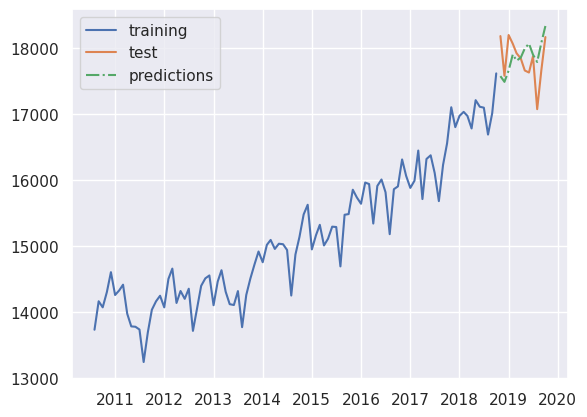

In [42]:
# predict next 12 months and plot
H = 12
WINDOW_SIZE = 12 # this is the number of lags included in the model

# data used for prediction
# we need to include the last 12 months of the standardised data
model_input_data = train_scaled[-WINDOW_SIZE:]

# generate the predictions using the iterative forecast
y_preds_lm = autoregressive_iterative_forecast(model_lm, model_input_data, h=H)

# reshape the predictions and back transform
y_preds_lm = scaler.inverse_transform(y_preds_lm.reshape(-1, 1))

# plot
plot_nn_prediction_results(admit_rate_train, admit_rate_test, y_preds_lm)

In [43]:
rmse_lm = root_mean_squared_error(y_preds_lm, admit_rate_test)
print(f"RMSE(Linear Model) = {rmse_lm:.1f}")

RMSE(Linear Model) = 378.4


# **Exercise 3:** Training a non-linear deep network

Now that you have got the basic structure and mechanics of the code you need for forecasting let's build a more complex model and compare the RMSE on the validation set to your simple linear model.

**Task:** 
* Create a new neural network model with 2 hidden layers
* Try 32 and 64 neurons for layer 1 and 2 respectively
* Use a ReLU activation function.
* Use the Adam optimiser with a learning rate of 0.01
* Predict the next 12 months ahead
* Calculate the RMSE

**Hints:**
* Feel free to experiment with the number of hidden layers, neurons and learning rate.
* Perhaps try a dropout layer(s) if you feel your model is overfitting.
* Set a tensorflow random seed if you want to be able to reproduce your results e.g. 45676



In [29]:
def get_network_model(
    ws, 
    n_neurons_l1=5, 
    n_neurons_l2=5,
    include_layer_two=False, 
    include_drop_out=False,
    drop_out_rate=0.2, 
    lr=0.001, 
    metrics=None
):
    '''
    A function to build/compile the network based on a number of user
    set parameters
    '''
    if metrics is None:
        metrics = ['mse']
        
    model = Sequential()
    model.add(Flatten(input_shape=(ws,)))
    model.add(Dense(n_neurons_l1, activation='relu'))
    if include_layer_two:
        model.add(Dense(n_neurons_l2, activation='relu'))
    if include_drop_out:
        model.add(Dropout(drop_out_rate))

    # output layer
    model.add(Dense(1))
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=lr),
                  metrics=metrics)
    return model

In [30]:
# set tensorflow random seed
tf.random.set_seed(1234)

N_EPOCHS = 200

# Neural network model
# We will try drop-out to regularise the model
mlp = get_network_model(
    ws=12, 
    n_neurons_l1=5, 
    include_layer_two=True, 
    n_neurons_l2=5,
    include_drop_out=False,
    drop_out_rate=0.2,
)

# fit model silently
results_mlp = mlp.fit(
    x=X_train, 
    y=y_train, 
    epochs=N_EPOCHS,
    validation_split=0.1,
    verbose=0
)

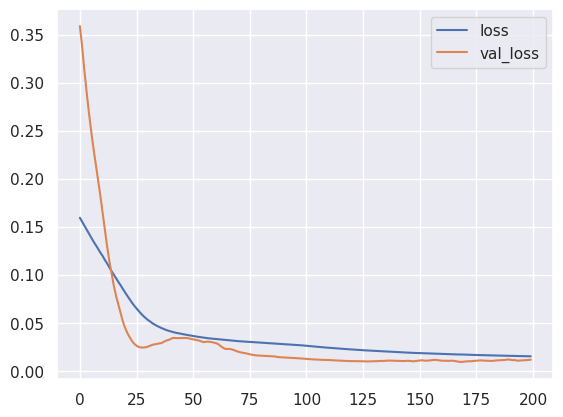

In [31]:
_ = plt.plot(results_mlp.history['loss'], label='loss')
_ = plt.plot(results_mlp.history['val_loss'], label='val_loss')
_ = plt.legend()

3/3 [==============================] - 0s 745us/step


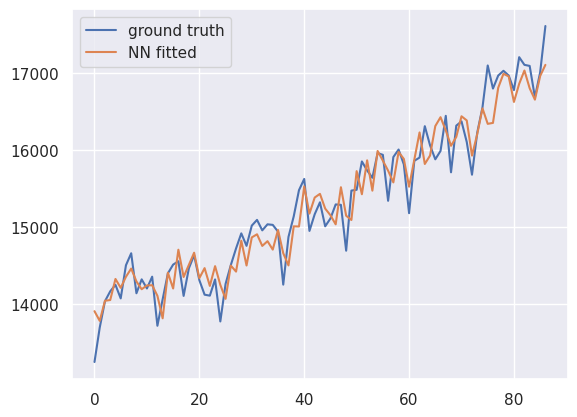

In [32]:
# make the predictions
in_sample_preds = mlp.predict(X_train)

# back transform to original units
back_transformed_preds = scaler.inverse_transform(in_sample_preds)

_ = plt.plot(scaler.inverse_transform(y_train.reshape(-1, 1)), label='ground truth')
_ = plt.plot(back_transformed_preds, label='NN fitted')

_ = plt.legend();

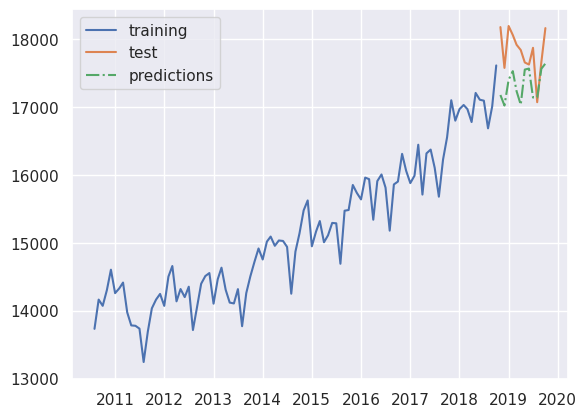

In [44]:
# predict next 12 months and plot
H = 12
WINDOW_SIZE = 12

# data used for prediction
# we need to include the last 12 months of the standardised data
model_input_data = train_scaled[-WINDOW_SIZE:]

# generate the predictions using the iterative forecast
y_preds_mlp = autoregressive_iterative_forecast(mlp, model_input_data, h=H)

# reshape the predictions and back transform
y_preds_mlp = scaler.inverse_transform(y_preds_mlp.reshape(-1, 1))

# plot the predictions
plot_nn_prediction_results(admit_rate_train, admit_rate_test, y_preds_mlp)

In [45]:
# calculate forecast error of the non-linear model
rmse_mlp = root_mean_squared_error(y_preds_mlp, admit_rate_test)

# a reminder of the linear model test error
print(f"RMSE(Linear Model) = {rmse_lm:.1f}")
print(f"RMSE(Neural Network) = {rmse_mlp:.1f}")

RMSE(Linear Model) = 378.4
RMSE(Neural Network) = 589.8


# Ensemble Learning

In all of the examples above we have been setting a random seed for tensorflow.  This 'suggests' that if we used a different randon number seed we would get a slightly different result (this is due to both random initialisation of weights/biases and stochastic gradient descent). Neural networks are extremely flexible and have many parameters. This leads to one of the key challenges with neural networks - overfitting.  There are multiple ways to deal with overfitting.  In forecasting a common approach is to use an **ensemble** of models.  

In an ensemble we train multiple models. 

## Training an ensemble

We will train an ensemble of neural networks that mimic a linear model.  

The code below has been provided for you to work through.

* We set some parameters e.g. number of models in an the ensemble: 20 to 30 should be plenty.
* We use a python loop to create and train each model and store the model in a python list.
    * Optionally we can save the models to file and load pre-trained versions at a later date.
* To predict we the need to loop through the collection of models.

In [87]:
def load_pretrained_ensemble(n_models):
    '''
    Load the pre-trained ensemble models (only use if they exist!)
    '''
    models = []
    url = './input'
    for n in range(n_models):
        model_n = tf.keras.models.load_model(f'{url}/ensemble_model_{n}.keras')
        models.append(model_n)
    return models

In [88]:
# script to train the models.

# ################ Parameters for the ensemble #################################
# set random seed so that ensemble can be repeated.
tf.random.set_seed(1085)

# number of models to create...
N_MODELS = 20

# max no. of epochs for training of each model.
N_EPOCHS = 100

# no. of autoregressive lags
WINDOW_SIZE = 12

# early stopping reguluarization
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# I've pretrained 50 models you can load them from file if wanted.
LOAD_FROM_FILE = False

###############################################################################

if LOAD_FROM_FILE:
    #it will take a few seconds to load.
    models = load_pretrained_ensemble(N_MODELS)
else:
    print("# Training model: ", end="")
    models = []
    for n in range(N_MODELS):
        print(f"{n+1},", end="")
        # linear network
        model_n = get_linear_model(WINDOW_SIZE)

        # fit model silently (verbose=0)
        history = model_n.fit(
            x=X_train, 
            y=y_train, 
            epochs=N_EPOCHS,
            verbose=0, 
            callbacks=[es], 
            validation_split=0.1
        )

        # this will overwrite pre-trained models.
        model_n.save(f'input/ensemble_model_{n}.keras')
        models.append(model_n)

print("Training of ensemble complete")

# Training model: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,Training of ensemble complete


### Predictions in an ensemble

In an ensemble, we predict in a loop. In python this is straightfoward as we simply loop through the models we have trained and call `autoregressive_iterative_forecast`. We will store the predictions of each forecast in a python `list`  called `e_preds`

<div class="alert alert-info">
    
In an ensemble we end up with a distribution of forecasts!  For point forecasts we could then take the median of the forecasts.  We can also get a measure of variability in the forecasts by calculating the quantiles. 
    
</div>



In [89]:
# create the forecasts
# this code will take a few seconds to execute
H = 12
WINDOW_SIZE = 12 # no. lags in the model

# stores ensemble predictions...
e_preds = []

# data used for prediction
# we need to include the last 12 months of the standardised data
model_input_data = train_scaled[-WINDOW_SIZE:]

# loop through all models in the ensemble
print("Predicting using ensemble. Please wait.")
for model in models:
    # iterative forecast for model_i
    y_preds = autoregressive_iterative_forecast(model, model_input_data, h=H)
    e_preds.append(y_preds)

e_preds = np.array(e_preds)
print("All predictions complete")

Predicting using ensemble. Please wait.
All predictions complete


In [90]:
# 20 models all provided a forecast with horizon = 12 months
e_preds.shape

(20, 12)

Inverse transform the data and calculate the median and 0.025 and 0.975 percentiles of the point forecasts

Remember we can use `scaler.inverse_transform()`

In [91]:
e_preds = np.asarray(e_preds)
e_preds_tran = scaler.inverse_transform(e_preds).T
y_preds_mdn = np.percentile(e_preds_tran.T, 50, axis=0)
y_preds_2_5 = np.percentile(e_preds_tran.T, 2.5, axis=0)
y_preds_97_5 = np.percentile(e_preds_tran.T, 97.5, axis=0)
y_preds_mdn.shape

(12,)

In [92]:
from typing import Tuple, Optional, Union
from numpy.typing import ArrayLike

def plot_ensemble_forecasts(
    y_test: ArrayLike,
    ensemble_forecasts: ArrayLike,
    y_median: ArrayLike,
    y_lower: ArrayLike,
    y_upper: ArrayLike,
    figsize: Tuple[int, int] = (12, 4),
    title_suffix: str = ""
) -> plt.Figure:
    """
    Plots individual ensemble traces and the aggregate prediction intervals against 
    test data.

    Parameters
    ----------
    y_test : ArrayLike
        The ground truth test data (1D array).
    ensemble_forecasts : ArrayLike
        Raw forecasts from all models. Shape should be (n_timesteps, n_models).
    y_median : ArrayLike
        The median forecast (1D array).
    y_lower : ArrayLike
        The lower bound of the prediction interval (e.g., 2.5 percentile).
    y_upper : ArrayLike
        The upper bound of the prediction interval (e.g., 97.5 percentile).
    figsize : Tuple[int, int], optional
        Width and height of the figure in inches. Default is (12, 4).
    title_suffix : str, optional
        String to append to the subplot titles (e.g., " - ARIMA"). Default is empty.

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object.
    """
    # Ensure inputs are numpy arrays for consistent indexing
    y_test = np.array(y_test).flatten()
    y_median = np.array(y_median).flatten()
    y_lower = np.array(y_lower).flatten()
    y_upper = np.array(y_upper).flatten()
    ensemble_forecasts = np.array(ensemble_forecasts)
    
    n_models = ensemble_forecasts.shape[1]
    time_steps = np.arange(len(y_test))

    fig, ax = plt.subplots(1, 2, sharey=True, figsize=figsize)

    # --- Plot 1: Spaghetti Plot (Individual Traces) ---
    # Plot ensemble members with high transparency to show density
    ax[0].plot(
        ensemble_forecasts, 
        color='gray', 
        alpha=0.2, 
        linewidth=0.8,
        label='_nolegend_' # Hide from legend to prevent 100 entries
    )
    
    # Add a dummy line just for the legend entry
    ax[0].plot([], [], color='gray', alpha=0.5, label='Ensemble members')
    
    # Plot Median and Test
    ax[0].plot(y_median, label='Median', linestyle='-', color='black', linewidth=1.5)
    ax[0].plot(y_test, label='Test Actual', linestyle='--', color='red', linewidth=1.5)
    
    ax[0].set_title(f'Point forecasts: {n_models} models{title_suffix}')
    ax[0].legend(loc='upper left')
    ax[0].grid(True, alpha=0.3)
    ax[0].set_xlabel("Forecast Horizon")
    ax[0].set_ylabel("Admit Rate")

    # --- Plot 2: Prediction Intervals (Shaded Region) ---
    # Plot Test and Median
    ax[1].plot(y_test, label='Test Actual', linestyle='--', color='red', linewidth=1.5)
    ax[1].plot(y_median, label='Median', linestyle='-', color='black', linewidth=1.5)
    
    # Plot Shaded Interval
    ax[1].fill_between(
        time_steps, 
        y_lower, 
        y_upper, 
        color='gray', 
        alpha=0.3, 
        label='95% Prediction Interval'
    )
    
    # Optional: Keep the lines for sharp boundaries if preferred
    ax[1].plot(y_lower, linestyle=':', color='gray', alpha=0.5, linewidth=1)
    ax[1].plot(y_upper, linestyle=':', color='gray', alpha=0.5, linewidth=1)

    ax[1].set_title(f'Uncertainty (Middle 95%){title_suffix}')
    ax[1].legend(loc='upper left')
    ax[1].grid(True, alpha=0.3)
    ax[1].set_xlabel("Forecast Horizon")

    plt.tight_layout()
    return fig

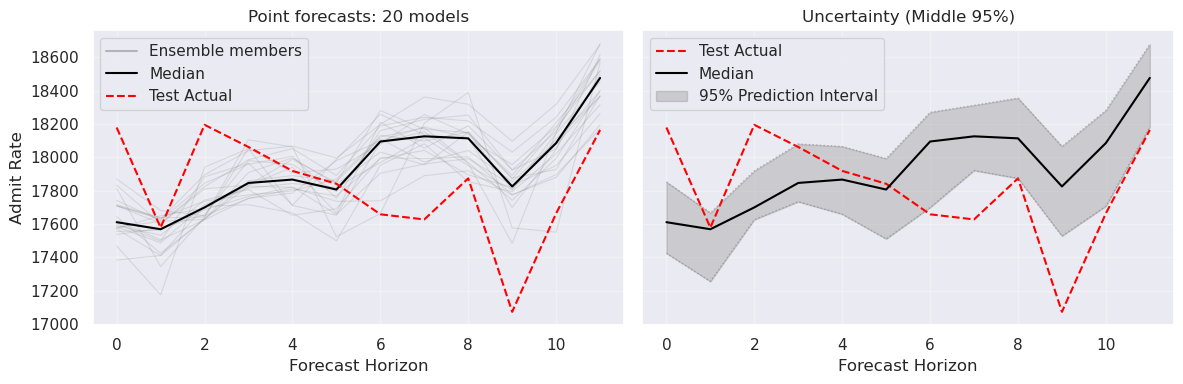

In [93]:
# Assuming your variables are defined as in your snippet
fig = plot_ensemble_forecasts(
    y_test=admit_rate_test, 
    ensemble_forecasts=e_preds_tran,
    y_median=y_preds_mdn, 
    y_lower=y_preds_2_5, 
    y_upper=y_preds_97_5
)

plt.show()

In [94]:
# calculate forecast error of the ensemble of linear models
rmse_el = root_mean_squared_error(y_preds_mdn, admit_rate_test)

# a reminder of the linear model test error
print(f"RMSE(Linear Model) = {rmse_lm:.1f}")
print(f"RMSE(Neural Network) = {rmse_mlp:.1f}")
print(f"RMSE(Linear Ensemble) = {rmse_el:.1f}")

RMSE(Linear Model) = 378.4
RMSE(Neural Network) = 589.8
RMSE(Linear Ensemble) = 404.1


In [98]:
# Let's have a look at the variability in the predictions across models.
rmse_25 = root_mean_squared_error(y_preds_2_5, admit_rate_test)
rmse_975 = root_mean_squared_error(y_preds_97_5, admit_rate_test)

print(f'95% of linear models will have rmse between: {rmse_25:.1f} - {rmse_975:.1f}')

95% of linear models will have rmse between: 363.0 - 495.4


**Question**: Is the ensemble approach useful?  What does it tell us about our original linear model?

## Exercise 4: Create an ensemble of non-linear models.

Is the two layer model more accurate than the simple linear regression model and its ensemble counterpart?

**Task:** 

* Create an ensemble of 20 models.
* Each model should be based on your solution to exercise 2 (e.g. a neural network with 2 hidden layers)
* Optional: save your models to file. (recommended)
* Forecast the next 12 periods.
* Calculate the RMSE of the forecast.


**Hints:**

* You have **all of the code** you need to complete this task!
* Remember to back transform your forecasts
* Use the median of the ensemble.
* Look carefully at the previous ensemble example.

**Questions**
* Which out of the simple linear, multi-layer and ensemble models do you think is best in this instance?

In [69]:
import os

In [70]:
# set tensorflow random seed for repeatability
tf.random.set_seed(1066)

N_MODLES = 20
N_EPOCHS = 100
H = 12
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
BATCH_SIZE = 32
output_directory = "./output"

# make if not present.
if not os.path.exists(output_directory):
    os.makedirs(output_directory)


models = []
print("# Training model: ", end="")
for n in range(N_MODELS):
    print(f"{n+1},", end="")
    # multi-layer model
    model_n = get_network_model(ws=12, 
                                n_neurons_l1=5,
                                include_layer_two=True,
                                n_neurons_l2=32,
                                lr=0.1)

    #fit model silently
    history = model_n.fit(x=X_train, 
                          y=y_train, 
                          epochs=N_EPOCHS,
                          verbose=0,
                          validation_split=0.1)

    mlp = get_network_model(
    ws=12, 
    n_neurons_l1=5, 
    include_layer_two=True, 
    n_neurons_l2=5,
    include_drop_out=False,
    drop_out_rate=0.2,
)


    #this will overwrite pre-trained models.
    model_n.save(f'output/mlp_ensemble_{n}.keras')
    models.append(model_n)

print("Training of ensemble complete.")

In [73]:
# this code will take a few seconds to execute
H = 12
WINDOW_SIZE = 12 # no. lags in the model

# stores ensemble predictions...
e_preds = []

# data used for prediction
# we need to include the last 12 months of the standardised data

model_input_data = train_scaled[-WINDOW_SIZE:]

print("Predicting using ensemble. Please wait.")
for model in models:
    y_preds = autoregressive_iterative_forecast(model, model_input_data, h=H)
    e_preds.append(y_preds)
    
e_preds = np.array(e_preds)

print("Ensemble predictions complete.")

Predicting using ensemble. Please wait.
Ensemble predictions complete.


In [74]:
e_preds = np.asarray(e_preds)
e_preds_tran = scaler.inverse_transform(e_preds).T
y_preds_mdn = np.percentile(e_preds_tran.T, 50, axis=0)
y_preds_2_5 = np.percentile(e_preds_tran.T, 2.5, axis=0)
y_preds_97_5 = np.percentile(e_preds_tran.T, 97.5, axis=0)
y_preds_mdn.shape

(12,)

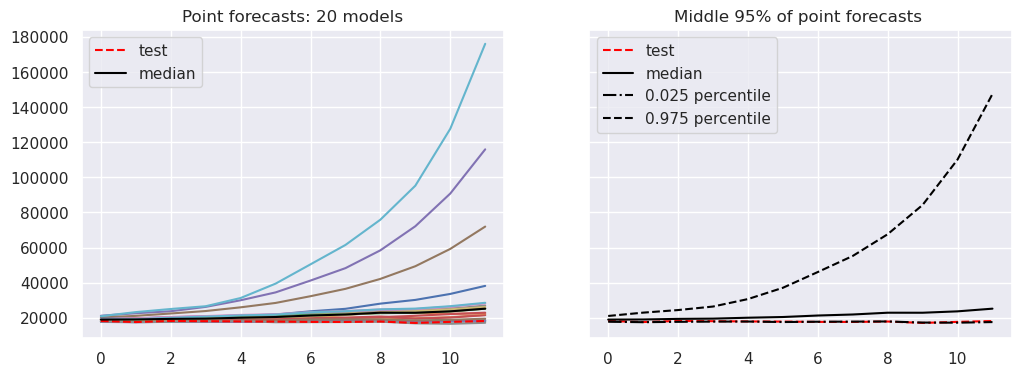

In [76]:
# plot the individual forecasts and the median

fig,ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
ax[0].plot(e_preds_tran)
ax[0].plot(scaler.inverse_transform(y_test), label='test', linestyle='--', 
         color='red')
ax[0].plot(y_preds_mdn, label='median', linestyle='-', color='black')
ax[0].legend()
ax[0].set_title(f'Point forecasts: {N_MODELS} models')

ax[1].plot(scaler.inverse_transform(y_test), label='test', linestyle='--', 
         color='red')
ax[1].plot(y_preds_mdn, label='median', linestyle='-', color='black')
ax[1].plot(y_preds_2_5, label='0.025 percentile', linestyle='-.', color='black')
ax[1].plot(y_preds_97_5, label='0.975 percentile', linestyle='--', color='black')
#ax[1].plot(y_preds_lm, label='original lmforecast', linestyle='--', color='green')
ax[1].set_title(f'Middle 95% of point forecasts ')
ax[1].legend();

In [ ]:
rmse_lm = rmse(scaler.inverse_transform(y_test), y_preds_mlp)[0]
rmse_mdn = rmse(scaler.inverse_transform(y_test.T), y_preds_mdn)[0]

print(f'rmse lm: {rmse_mlp:.2f}\nrmse ensemble: {rmse_mdn:.2f}')

## Optional Extra exercise for you to think about.
* How would you use a ensemble method with a model that predicts a vector?

# End of lab